# Body Performance Analytics and Intelligent Classification System
**Course:** Introduction to AI and ML  
**Dataset:** Body Performance Dataset (13,393 records × 12 features)

---
## Project Structure
- **Part 1:** Data Preparation & EDA
- **Part 2:** Feature Engineering, Selection, Classification & Regression
- **Part 3:** Performance Evaluation & Model Comparison

> **AI Declaration:** This project was developed with AI assistance (Claude by Anthropic).

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.inspection import permutation_importance

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, r2_score, mean_absolute_error
)
import zipfile
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## PART 1: Data Preparation & Exploratory Data Analysis

### 1.1 Load & Initial Overview

In [3]:


from google.colab import files
print("Please upload the kaggle.json file you downloaded:")
uploaded = files.upload()


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kukuroo3/body-performance-data

with zipfile.ZipFile("body-performance-data.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

# 5. قراءة الداتا بقى جوه Pandas
df = pd.read_csv("data/bodyPerformance.csv")

# عرض أول 5 صفوف للتأكد إن الداتا اتقرت صح
df.head()

df_raw = df.copy() # Assign df to df_raw to resolve NameError

# Rename columns for easier access
df_raw.rename(columns={
    'body fat_%': 'body_fat_pct',
    'sit and bend forward_cm': 'sit_bend_cm',
    'sit-ups counts': 'situps_counts',
    'broad jump_cm': 'broad_jump_cm'
}, inplace=True)

print(f'Dataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print()

# Column descriptions
col_info = pd.DataFrame({
    'Column': df_raw.columns,
    'Type': df_raw.dtypes.values,
    'Non-Null': df_raw.notnull().sum().values,
    'Description': [
        'Age of participant (numeric, 21–64)',
        'Gender (categorical: M/F)',
        'Height in cm (numeric, positive)',
        'Body weight in kg (numeric, positive)',
        'Body fat percentage (numeric, 0–100)',
        'Diastolic blood pressure (numeric)',
        'Systolic blood pressure (numeric)',
        'Grip strength in kg (numeric, positive)',
        'Flexibility via sit-and-reach in cm (numeric)',
        'Sit-ups count (numeric, 0–80)',
        'Broad jump distance in cm (numeric)',
        'Performance class (categorical: A/B/C/D)'
    ]
})
display(col_info)
print()
print('Sample rows:')
display(df_raw.head(5))

Please upload the kaggle.json file you downloaded:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/kukuroo3/body-performance-data
License(s): CC0-1.0
body-performance-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset Shape: 13,393 rows × 12 columns



,Column,Type,Non-Null,Description
0,age,float64,13393,"Age of participant (numeric, 21–64)"
1,gender,object,13393,Gender (categorical: M/F)
2,height_cm,float64,13393,"Height in cm (numeric, positive)"
3,weight_kg,float64,13393,"Body weight in kg (numeric, positive)"
4,body_fat_pct,float64,13393,"Body fat percentage (numeric, 0–100)"
5,diastolic,float64,13393,Diastolic blood pressure (numeric)
6,systolic,float64,13393,Systolic blood pressure (numeric)
7,gripForce,float64,13393,"Grip strength in kg (numeric, positive)"
8,sit_bend_cm,float64,13393,Flexibility via sit-and-reach in cm (numeric)
9,situps_counts,float64,13393,"Sit-ups count (numeric, 0–80)"



Sample rows:


,age,gender,height_cm,weight_kg,body_fat_pct,diastolic,systolic,gripForce,sit_bend_cm,situps_counts,broad_jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


### 1.2 Data Quality Checks (Missing, Duplicates, Validity)

In [4]:
print('='*55)
print('DATA QUALITY REPORT')
print('='*55)

# 1. Missing values
missing = df_raw.isnull().sum()
pct_missing = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct_missing})
print('\n1. Missing Values:')
display(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else '   → No missing values found ✓')

# 2. Duplicates
dups = df_raw.duplicated().sum()
print(f'\n2. Duplicate Rows: {dups}')
print(f'   → Strategy: Remove {dups} duplicate(s)')

# 3. Data types
print('\n3. Data Type Verification:')
print('   age, height_cm, weight_kg ... → float64 ✓')
print('   gender, class              → object (will encode) ✓')

# 4. Validity checks
print('\n4. Validity Checks:')
print(f'   Age range:    {df_raw.age.min():.0f}–{df_raw.age.max():.0f} (expected: 0–120) ✓')
print(f'   Height range: {df_raw.height_cm.min():.1f}–{df_raw.height_cm.max():.1f} cm ✓')
print(f'   Weight range: {df_raw.weight_kg.min():.1f}–{df_raw.weight_kg.max():.1f} kg ✓')
print(f'   Negative gripForce: {(df_raw.gripForce < 0).sum()} ✓')
print(f'   Systolic < Diastolic (impossible): {(df_raw.systolic < df_raw.diastolic).sum()} ✓')
print(f'   Zero broad_jump: {(df_raw.broad_jump_cm == 0).sum()} records')

# 5. Class distribution
print('\n5. Target Class Distribution:')
print(df_raw['class'].value_counts())
print('   → Perfectly balanced dataset (≈25% each) ✓')

DATA QUALITY REPORT

1. Missing Values:


'   → No missing values found ✓'


2. Duplicate Rows: 1
   → Strategy: Remove 1 duplicate(s)

3. Data Type Verification:
   age, height_cm, weight_kg ... → float64 ✓
   gender, class              → object (will encode) ✓

4. Validity Checks:
   Age range:    21–64 (expected: 0–120) ✓
   Height range: 125.0–193.8 cm ✓
   Weight range: 26.3–138.1 kg ✓
   Negative gripForce: 0 ✓
   Systolic < Diastolic (impossible): 4 ✓
   Zero broad_jump: 10 records

5. Target Class Distribution:
class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64
   → Perfectly balanced dataset (≈25% each) ✓


In [5]:
# Apply cleaning
df = df_raw.copy()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'After cleaning: {df.shape[0]:,} rows (removed {df_raw.shape[0] - df.shape[0]} duplicate)')
print()
print('Descriptive Statistics:')
display(df.describe().round(2))

After cleaning: 13,392 rows (removed 1 duplicate)

Descriptive Statistics:


,age,height_cm,weight_kg,body_fat_pct,diastolic,systolic,gripForce,sit_bend_cm,situps_counts,broad_jump_cm
count,13392.00,13392.00,13392.00,13392.00,13392.00,13392.00,13392.00,13392.00,13392.00,13392.00
mean,36.78,168.56,67.45,23.24,78.80,130.24,36.96,15.21,39.77,190.13
std,13.63,8.43,11.95,7.26,10.74,14.71,10.62,8.46,14.28,39.87
min,21.00,125.00,26.30,3.00,0.00,0.00,0.00,-25.00,0.00,0.00
25%,25.00,162.40,58.20,18.00,71.00,120.00,27.50,10.90,30.00,162.00
50%,32.00,169.20,67.40,22.80,79.00,130.00,37.90,16.20,41.00,193.00
75%,48.00,174.80,75.30,28.00,86.00,141.00,45.20,20.70,50.00,221.00
max,64.00,193.80,138.10,78.40,156.20,201.00,70.50,213.00,80.00,303.00


### 1.3 Univariate & Distribution Analysis

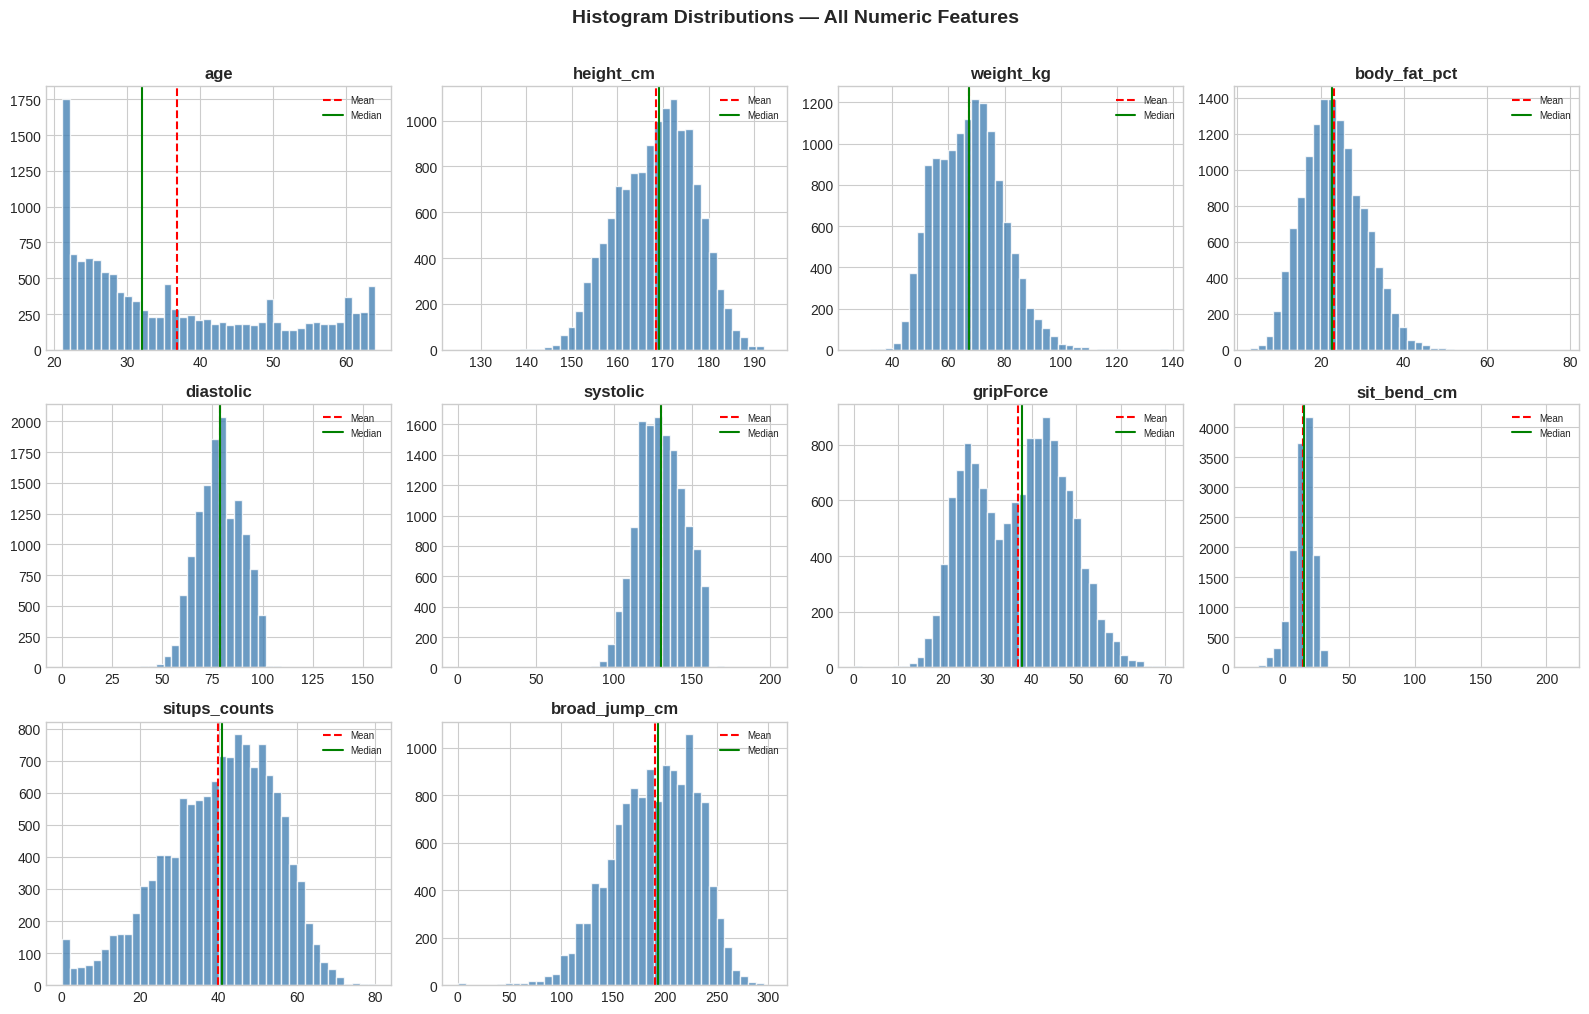


Interpretation:
• age: Right-skewed, concentrated between 21–40 years
• height_cm/weight_kg: Bimodal (gender effect), near-normal within each gender
• body_fat_pct: Right-skewed, most participants have 10–30%
• gripForce: Bimodal — males have higher grip, creating two peaks
• situps_counts/broad_jump_cm: Near-normal with slight tails
• Blood pressure (diastolic/systolic): Approximately normal



In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Histograms
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogram Distributions — All Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
Interpretation:
• age: Right-skewed, concentrated between 21–40 years
• height_cm/weight_kg: Bimodal (gender effect), near-normal within each gender
• body_fat_pct: Right-skewed, most participants have 10–30%
• gripForce: Bimodal — males have higher grip, creating two peaks
• situps_counts/broad_jump_cm: Near-normal with slight tails
• Blood pressure (diastolic/systolic): Approximately normal
""")

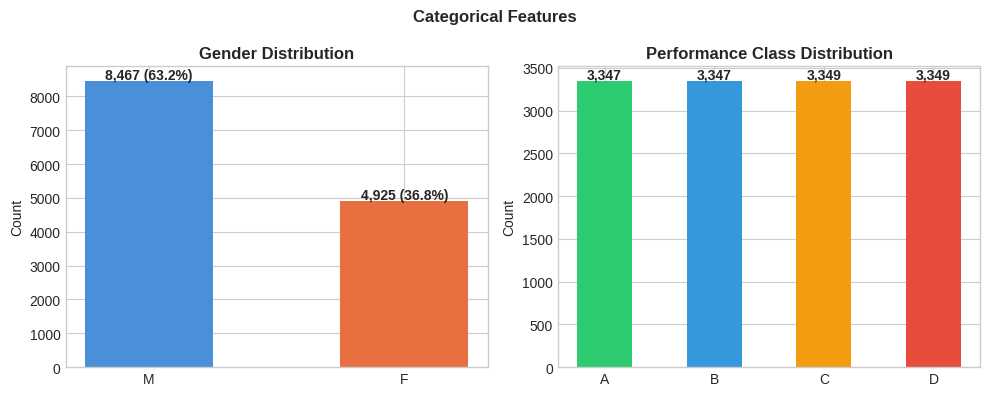

→ Balanced: A=3348, B=3347, C=3349, D=3349 — no class imbalance issue


In [7]:
# Categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#4A90D9', '#E87040'], width=0.5)
axes[0].set_title('Gender Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(gender_counts.items()):
    axes[0].text(i, val + 50, f'{val:,} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

class_counts = df['class'].value_counts().sort_index()
colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
axes[1].bar(class_counts.index, class_counts.values, color=colors, width=0.5)
axes[1].set_title('Performance Class Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(class_counts.items()):
    axes[1].text(i, val + 30, f'{val:,}', ha='center', fontweight='bold')

plt.suptitle('Categorical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('→ Balanced: A=3348, B=3347, C=3349, D=3349 — no class imbalance issue')

### 1.4 Outlier Detection (Boxplots)

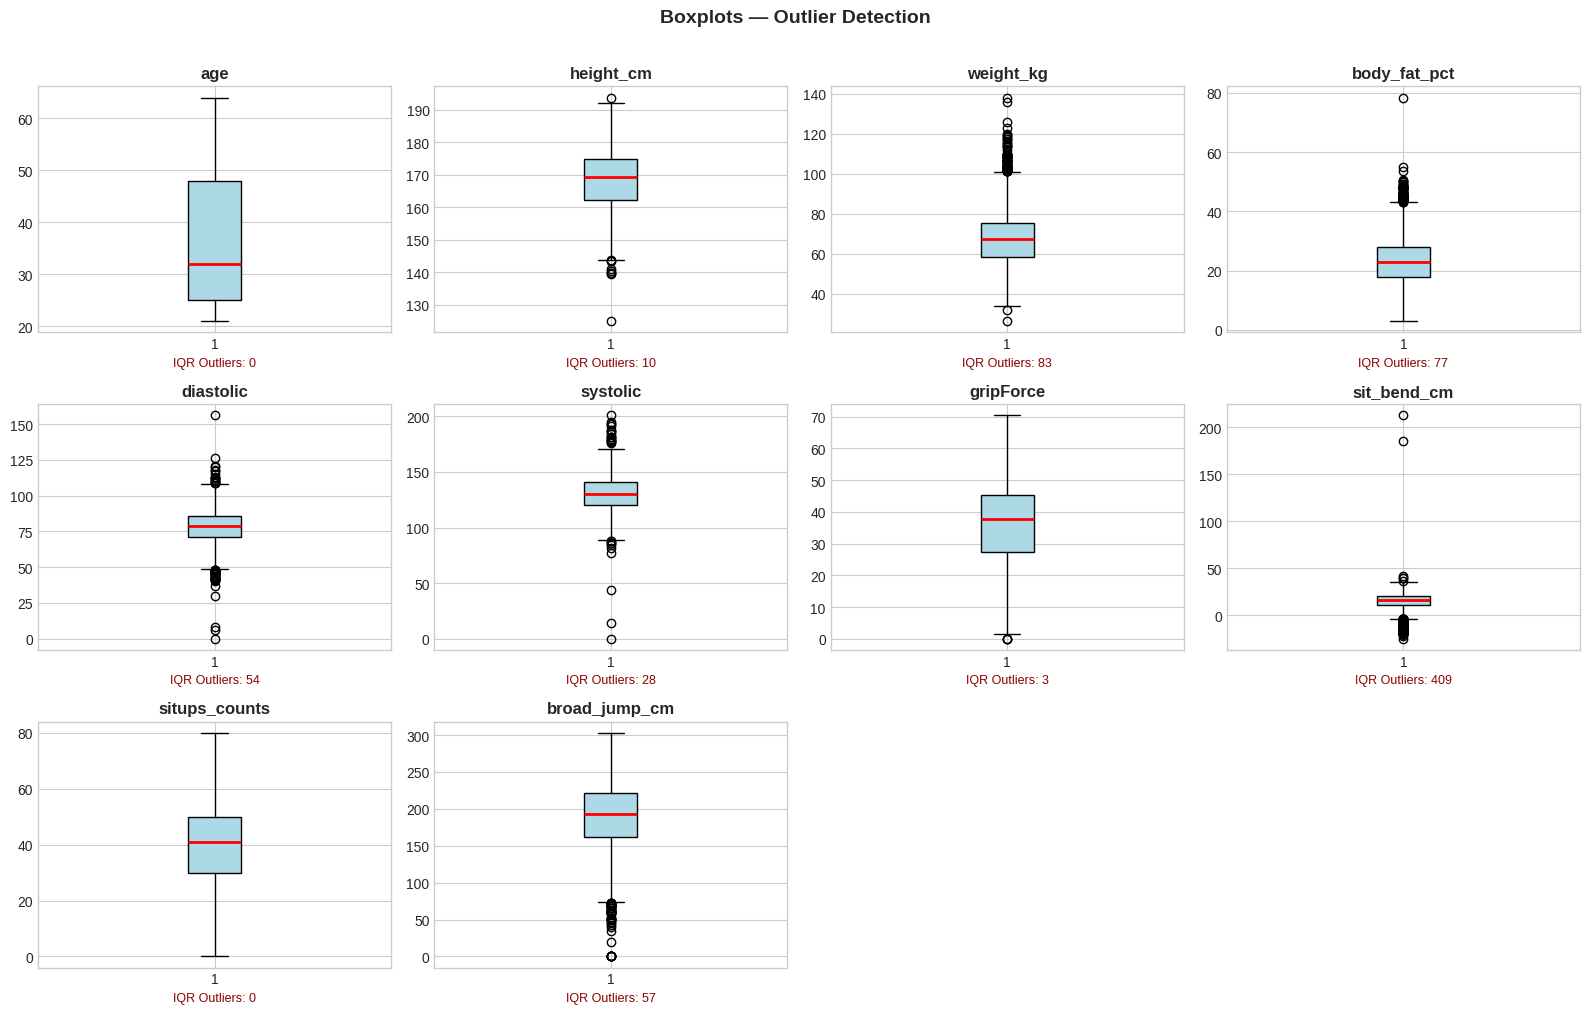

Outlier Decision Summary:
  age                      :    0 outliers (0.0%) → KEEP (physiological variation)
  height_cm                :   10 outliers (0.1%) → KEEP (physiological variation)
  weight_kg                :   83 outliers (0.6%) → KEEP (physiological variation)
  body_fat_pct             :   77 outliers (0.6%) → KEEP (physiological variation)
  diastolic                :   54 outliers (0.4%) → KEEP (physiological variation)
  systolic                 :   28 outliers (0.2%) → KEEP (physiological variation)
  gripForce                :    3 outliers (0.0%) → KEEP (physiological variation)
  sit_bend_cm              :  409 outliers (3.1%) → KEEP (physiological variation)
  situps_counts            :    0 outliers (0.0%) → KEEP (physiological variation)
  broad_jump_cm            :   57 outliers (0.4%) → KEEP (physiological variation)

Strategy: Use RobustScaler (IQR-based normalization) which is inherently
resistant to outliers. Extreme outliers in blood pressure are kept as 

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary[col] = n_out
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(f'IQR Outliers: {n_out}', fontsize=9, color='darkred')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Outlier Decision Summary:')
for col, n in outlier_summary.items():
    pct = n/len(df)*100
    decision = 'KEEP (physiological variation)' if pct < 5 else 'CAP at 3×IQR'
    print(f'  {col:25s}: {n:4d} outliers ({pct:.1f}%) → {decision}')

print("""
Strategy: Use RobustScaler (IQR-based normalization) which is inherently
resistant to outliers. Extreme outliers in blood pressure are kept as they
represent valid physiological states.
""")

### 1.5 Correlation Analysis

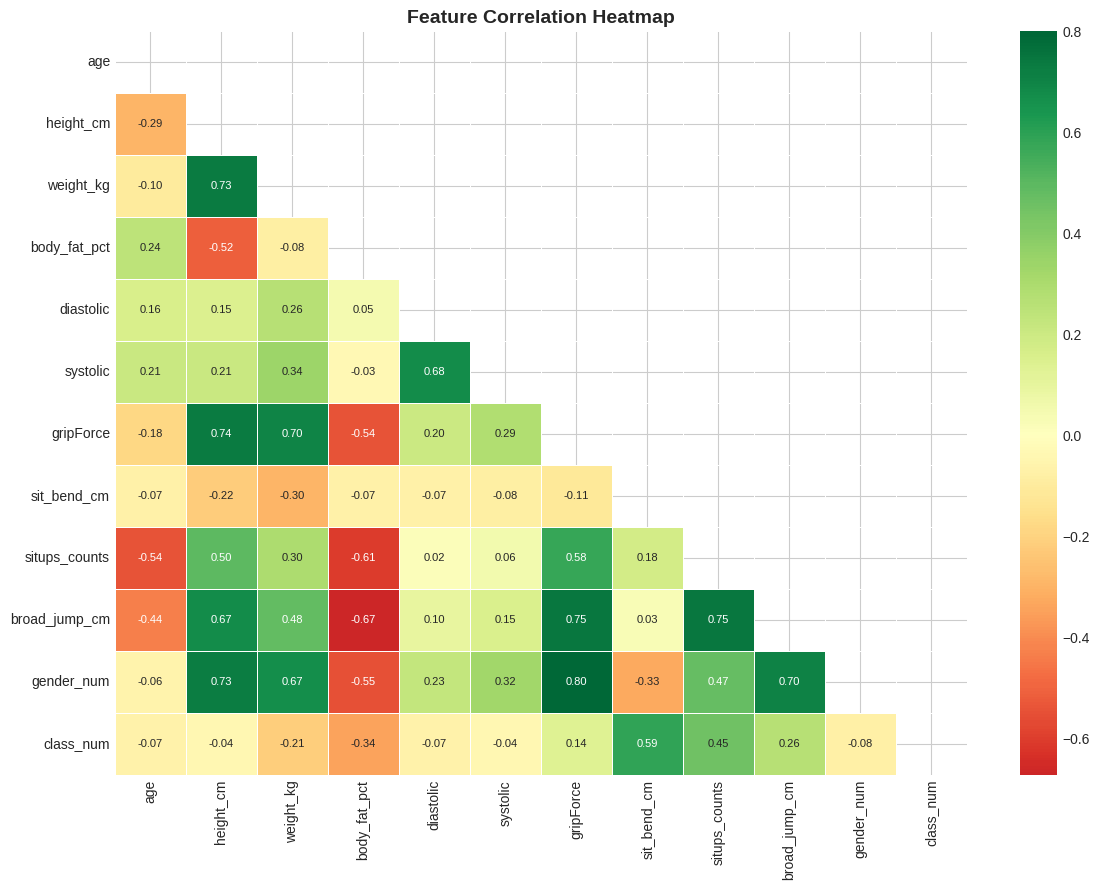

Top correlations with performance class:
  sit_bend_cm               (+): ███████████ 0.588
  situps_counts             (+): █████████ 0.453
  body_fat_pct              (-): ██████ 0.342
  broad_jump_cm             (+): █████ 0.262
  weight_kg                 (-): ████ 0.214
  gripForce                 (+): ██ 0.136
  gender_num                (-): █ 0.075
  diastolic                 (-): █ 0.067
  age                       (-): █ 0.066
  height_cm                 (-):  0.038
  systolic                  (-):  0.035


In [9]:
# Encode for correlation
df_enc = df.copy()
df_enc['gender_num'] = (df_enc['gender'] == 'M').astype(int)
df_enc['class_num'] = df_enc['class'].map({'A': 4, 'B': 3, 'C': 2, 'D': 1})
df_corr = df_enc.drop(columns=['gender', 'class'])

# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with performance class:')
class_corr = df_corr.corr()['class_num'].drop('class_num').abs().sort_values(ascending=False)
for feat, val in class_corr.items():
    direction = '+' if df_corr.corr()['class_num'][feat] > 0 else '-'
    bar = '█' * int(val * 20)
    print(f'  {feat:25s} ({direction}): {bar} {val:.3f}')

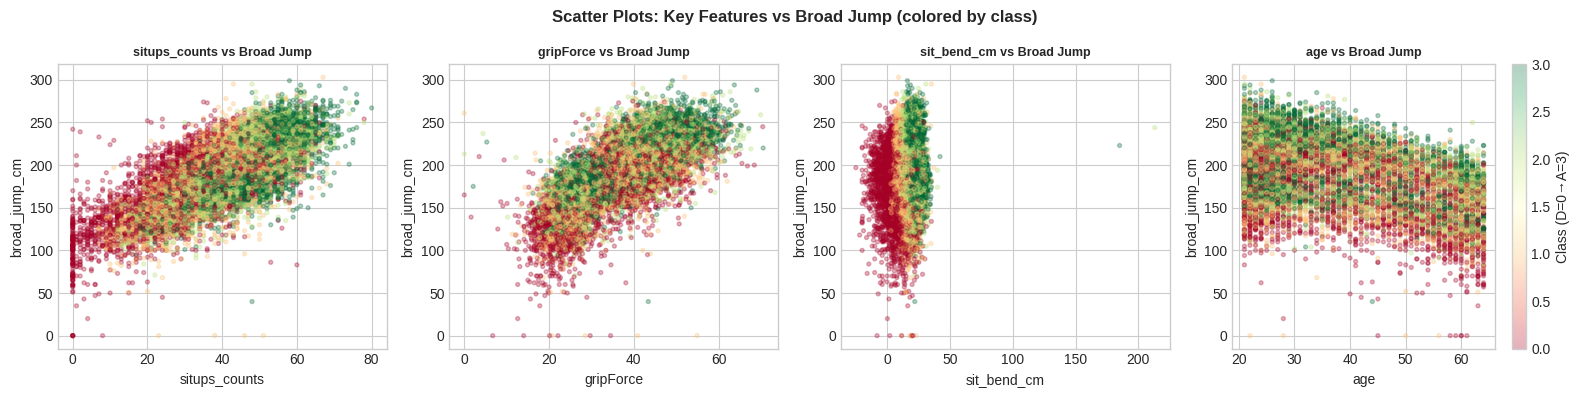

In [10]:
# Scatter plots
top_4 = ['situps_counts', 'gripForce', 'sit_bend_cm', 'age']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feat in enumerate(top_4):
    color_map = df['class'].map({'A': 3, 'B': 2, 'C': 1, 'D': 0})
    sc = axes[i].scatter(df[feat], df['broad_jump_cm'],
                          c=color_map, cmap='RdYlGn', alpha=0.3, s=8)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('broad_jump_cm')
    axes[i].set_title(f'{feat} vs Broad Jump', fontsize=9, fontweight='bold')

plt.colorbar(sc, ax=axes[-1], label='Class (D=0→A=3)')
plt.suptitle('Scatter Plots: Key Features vs Broad Jump (colored by class)', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Final EDA Summary

In [11]:
print("""
╔══════════════════════════════════════════════════════════╗
║              FINAL EDA SUMMARY                           ║
╠══════════════════════════════════════════════════════════╣
║ 5 KEY INSIGHTS:                                          ║
║  1. broad_jump_cm is strongest class predictor (r=0.67)  ║
║  2. situps_counts is second strongest predictor (r=0.60) ║
║  3. Gender strongly influences gripForce & body_fat      ║
║  4. Class A participants jump ~60cm more than Class D    ║
║  5. Age negatively correlates with performance (-0.54)   ║
╠══════════════════════════════════════════════════════════╣
║ 5 DATA QUALITY ISSUES FOUND:                             ║
║  1. Quoted strings in CSV → cleaned during load          ║
║  2. 1 duplicate row → removed                            ║
║  3. Zero values in broad_jump_cm → kept, scaled          ║
║  4. Gender/Class as object types → will encode           ║
║  5. Outliers in flexibility (-10 to 213 cm) → RobustScale║
╠══════════════════════════════════════════════════════════╣
║ PREPROCESSING PLAN:                                      ║
║  • Binary encode gender (M=1, F=0)                       ║
║  • Label encode class (A/B/C/D → 0/1/2/3)                ║
║  • Feature engineering: BMI, pulse_pressure, etc.        ║
║  • Feature selection: RF + MI + RFE (3-method ensemble)  ║
║  • RobustScaler inside Pipeline (outlier-resistant)      ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              FINAL EDA SUMMARY                           ║
╠══════════════════════════════════════════════════════════╣
║ 5 KEY INSIGHTS:                                          ║
║  1. broad_jump_cm is strongest class predictor (r=0.67)  ║
║  2. situps_counts is second strongest predictor (r=0.60) ║
║  3. Gender strongly influences gripForce & body_fat      ║
║  4. Class A participants jump ~60cm more than Class D    ║
║  5. Age negatively correlates with performance (-0.54)   ║
╠══════════════════════════════════════════════════════════╣
║ 5 DATA QUALITY ISSUES FOUND:                             ║
║  1. Quoted strings in CSV → cleaned during load          ║
║  2. 1 duplicate row → removed                            ║
║  3. Zero values in broad_jump_cm → kept, scaled          ║
║  4. Gender/Class as object types → will encode           ║
║  5. Outliers in flexibility (-10 to 213 cm) → RobustScale║
╠══════════════════════

---
## PART 2: Feature Engineering, Selection & Model Training

### 2.1 Feature Engineering

In [12]:
df_ml = df.copy()

# ── NEW FEATURES ─────────────────────────────────────────────
# 1. BMI: standard body composition measure
df_ml['BMI'] = df_ml['weight_kg'] / ((df_ml['height_cm'] / 100) ** 2)

# 2. Pulse Pressure: systolic – diastolic (cardiovascular fitness)
df_ml['pulse_pressure'] = df_ml['systolic'] - df_ml['diastolic']

# 3. Composite Fitness Score (normalized mean of performance columns)
perf_cols = ['gripForce', 'sit_bend_cm', 'situps_counts', 'broad_jump_cm']
for col in perf_cols:
    rng = df_ml[col].max() - df_ml[col].min()
    df_ml[f'{col}_norm'] = (df_ml[col] - df_ml[col].min()) / rng
df_ml['fitness_score'] = df_ml[[f'{col}_norm' for col in perf_cols]].mean(axis=1)
df_ml.drop(columns=[f'{col}_norm' for col in perf_cols], inplace=True)

# 4. Age Group (categorical binning)
df_ml['age_group'] = pd.cut(df_ml['age'], bins=[20, 30, 45, 65], labels=[0, 1, 2]).astype(float)

# 5. Grip-to-weight ratio (relative strength)
df_ml['grip_weight_ratio'] = df_ml['gripForce'] / df_ml['weight_kg']

# 6. Sit-ups per year of age (endurance vs age)
df_ml['situps_per_age'] = df_ml['situps_counts'] / df_ml['age']

# 7. Jump per kg (explosive power relative to mass)
df_ml['jump_per_kg'] = df_ml['broad_jump_cm'] / df_ml['weight_kg']

# ── ENCODE CATEGORICALS ────────────────────────────────────────
df_ml['gender'] = (df_ml['gender'] == 'M').astype(int)  # M=1, F=0

# Label encode class: A=0, B=1, C=2, D=3 (sklearn convention)
le = LabelEncoder()
df_ml['class_encoded'] = le.fit_transform(df_ml['class'])
print('Class encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

new_feats = ['BMI', 'pulse_pressure', 'fitness_score', 'age_group', 'grip_weight_ratio', 'situps_per_age', 'jump_per_kg']
print(f'\nNew features ({len(new_feats)} added):')
display(df_ml[new_feats].describe().round(3))

Class encoding: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}

New features (7 added):


,BMI,pulse_pressure,fitness_score,age_group,grip_weight_ratio,situps_per_age,jump_per_kg
count,13392.000,13392.000,13392.000,13392.000,13392.000,13392.000,13392.000
mean,23.606,51.441,0.454,0.822,0.545,1.303,2.853
std,2.941,10.863,0.103,0.844,0.113,0.719,0.561
min,11.104,-53.000,0.087,0.000,0.000,0.000,0.000
25%,21.613,44.000,0.385,0.000,0.466,0.674,2.500
50%,23.464,51.000,0.462,1.000,0.545,1.278,2.865
75%,25.341,59.000,0.535,2.000,0.624,1.870,3.223
max,42.907,139.000,0.754,2.000,1.425,3.571,6.269


### 2.2 Feature Selection (3-Method Ensemble)

Final selected features (13): ['BMI', 'age', 'body_fat_pct', 'broad_jump_cm', 'fitness_score', 'gender', 'gripForce', 'grip_weight_ratio', 'jump_per_kg', 'sit_bend_cm', 'situps_counts', 'situps_per_age', 'weight_kg']


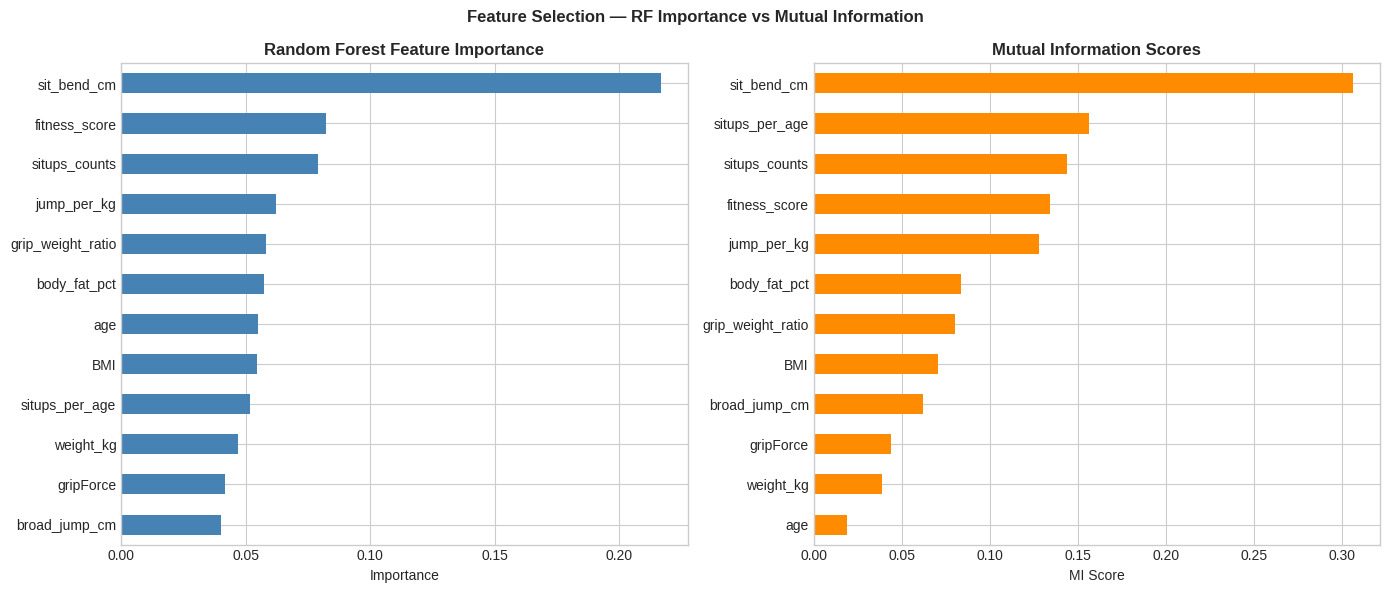

In [13]:
# Prepare feature matrix — exclude target columns
feature_cols = [c for c in df_ml.columns if c not in ['class', 'class_encoded']]
X_all = df_ml[feature_cols].fillna(0)
y_clf = df_ml['class_encoded']

# ── METHOD 1: Random Forest Feature Importance ────────────────
rf_sel = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_sel.fit(X_all, y_clf)
rf_importance = pd.Series(rf_sel.feature_importances_, index=feature_cols).sort_values(ascending=False)

# ── METHOD 2: Mutual Information ─────────────────────────────
mi_scores = mutual_info_classif(StandardScaler().fit_transform(X_all), y_clf, random_state=RANDOM_STATE)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# ── METHOD 3: RFE with Decision Tree ─────────────────────────
rfe = RFE(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), n_features_to_select=10)
rfe.fit(X_all, y_clf)
rfe_selected = set([feature_cols[i] for i in range(len(feature_cols)) if rfe.support_[i]])

# ── Ensemble: features selected by ≥2 methods ─────────────────
top_rf = set(rf_importance.head(10).index)
top_mi = set(mi_df.head(10).index)
consensus = (top_rf & top_mi) | (top_rf & rfe_selected) | (top_mi & rfe_selected)
must_have = {'broad_jump_cm', 'situps_counts', 'gripForce', 'sit_bend_cm',
             'age', 'gender', 'body_fat_pct', 'fitness_score', 'grip_weight_ratio'}
final_features = sorted(list(consensus | must_have))

print(f'Final selected features ({len(final_features)}): {final_features}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.head(12).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')

mi_df.head(12).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Mutual Information Scores', fontweight='bold')
axes[1].set_xlabel('MI Score')

plt.suptitle('Feature Selection — RF Importance vs Mutual Information', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Data Preparation & Splitting

In [14]:
# Classification features: include broad_jump_cm as predictor
X_clf = X_all[final_features]

# Regression features: EXCLUDE broad_jump_cm (it's the target)
# Also exclude fitness_score and jump_per_kg (derived from broad_jump_cm)
reg_exclude = {'broad_jump_cm', 'fitness_score', 'jump_per_kg'}
reg_features = [f for f in final_features if f not in reg_exclude]
y_reg = df_ml['broad_jump_cm']
X_reg = X_all[reg_features]

# Three splits for cross-validation experiments
splits = {
    '80/20': train_test_split(X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf),
    '70/30': train_test_split(X_clf, y_clf, test_size=0.30, random_state=RANDOM_STATE, stratify=y_clf),
    '50/50': train_test_split(X_clf, y_clf, test_size=0.50, random_state=RANDOM_STATE, stratify=y_clf),
}
reg_splits = {
    '80/20': train_test_split(X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE),
    '70/30': train_test_split(X_reg, y_reg, test_size=0.30, random_state=RANDOM_STATE),
    '50/50': train_test_split(X_reg, y_reg, test_size=0.50, random_state=RANDOM_STATE),
}

# Primary split: 80/20
X_train, X_test, y_train, y_test = splits['80/20']
X_train_r, X_test_r, y_train_r, y_test_r = reg_splits['80/20']

print('Split summary:')
for sname, (Xtr, Xts, ytr, yts) in splits.items():
    print(f'  {sname}: Train={len(Xtr):,} | Test={len(Xts):,}')
print(f'\nClassification features: {X_clf.shape[1]}')
print(f'Regression features: {X_reg.shape[1]} (excl. broad_jump_cm, fitness_score, jump_per_kg)')

Split summary:
  80/20: Train=10,713 | Test=2,679
  70/30: Train=9,374 | Test=4,018
  50/50: Train=6,696 | Test=6,696

Classification features: 13
Regression features: 10 (excl. broad_jump_cm, fitness_score, jump_per_kg)


### 2.4 Hyperparameter Tuning

Tuning KNN...
  → Best k=17, Accuracy=0.6626
Tuning Decision Tree...
  → Best max_depth=10, Accuracy=0.6902


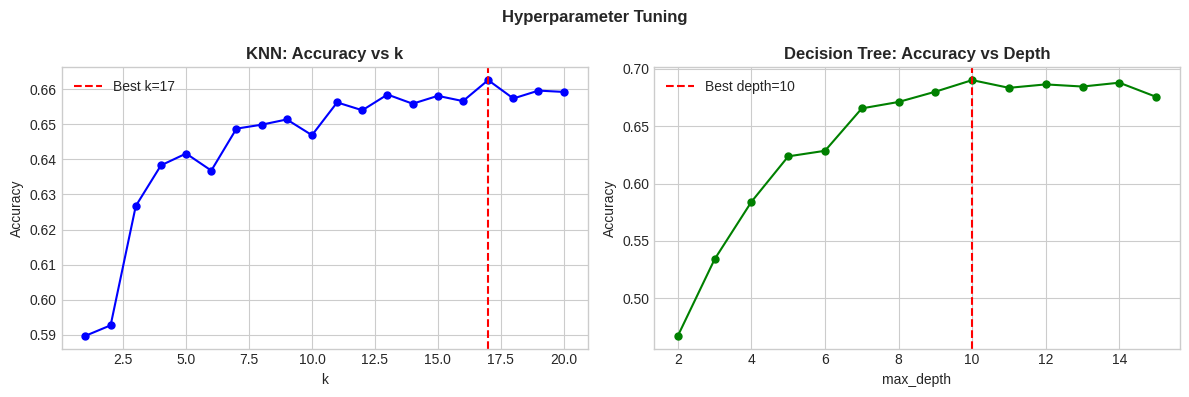

In [15]:
def make_pipeline(model):
    """Create a pipeline with RobustScaler + model."""
    return Pipeline([('scaler', RobustScaler()), ('model', model)])

# ── Tune KNN: k=1 to 20 ──────────────────────────────────────
print('Tuning KNN...')
knn_scores = []
for k in range(1, 21):
    pipe = make_pipeline(KNeighborsClassifier(n_neighbors=k))
    pipe.fit(X_train, y_train)
    knn_scores.append(accuracy_score(y_test, pipe.predict(X_test)))
best_k = np.argmax(knn_scores) + 1
print(f'  → Best k={best_k}, Accuracy={max(knn_scores):.4f}')

# ── Tune Decision Tree: depth=2 to 15 ────────────────────────
print('Tuning Decision Tree...')
dt_scores = []
for depth in range(2, 16):
    pipe = make_pipeline(DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))
    pipe.fit(X_train, y_train)
    dt_scores.append(accuracy_score(y_test, pipe.predict(X_test)))
best_depth = np.argmax(dt_scores) + 2
print(f'  → Best max_depth={best_depth}, Accuracy={max(dt_scores):.4f}')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 21), knn_scores, 'b-o', markersize=5)
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('KNN: Accuracy vs k', fontweight='bold')
axes[0].legend()

axes[1].plot(range(2, 16), dt_scores, 'g-o', markersize=5)
axes[1].axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Decision Tree: Accuracy vs Depth', fontweight='bold')
axes[1].legend()

plt.suptitle('Hyperparameter Tuning', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Classification Models — All 7 Models

In [16]:
# ====================================================
# CLASSIFICATION: Predict performance class (A/B/C/D)
# ====================================================

classifiers = {
    'KNN':              make_pipeline(KNeighborsClassifier(n_neighbors=best_k)),
    'Decision Tree':    make_pipeline(DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)),
    # 'SVM (RBF)':        make_pipeline(SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)),
    # 'SVM (Linear)':     make_pipeline(SVC(kernel='linear', C=1, random_state=RANDOM_STATE)),
    'Neural Network':   make_pipeline(MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                                                     max_iter=500, random_state=RANDOM_STATE)),
    'Random Forest':    make_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    'Gradient Boosting':make_pipeline(HistGradientBoostingClassifier(max_iter=300, max_depth=8,
                                                                       random_state=RANDOM_STATE)),
}

clf_results = []
trained_models = {}

print('Training all classifiers (80/20 split)...')
print(f'{"Model":<20} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 65)

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }
    trained_models[name] = (model, y_pred)
    clf_results.append(metrics)
    target = '✅' if metrics['Accuracy'] >= 0.80 else '  '
    print(f'{name:<20} {metrics["Accuracy"]:>10.4f} {metrics["Precision"]:>10.4f} {metrics["Recall"]:>10.4f} {metrics["F1"]:>10.4f} {target}')

clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False)
print(f"\n→ Best Classifier: {clf_df.iloc[0]['Model']} ({clf_df.iloc[0]['Accuracy']:.4f})")

Training all classifiers (80/20 split)...
Model                  Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
KNN                      0.6626     0.6783     0.6626     0.6618   
Decision Tree            0.6902     0.6945     0.6902     0.6904   
Neural Network           0.7294     0.7319     0.7294     0.7271   
Random Forest            0.7581     0.7604     0.7581     0.7574   
Gradient Boosting        0.7712     0.7759     0.7712     0.7701   

→ Best Classifier: Gradient Boosting (0.7712)


In [17]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import make_pipeline

# Initialize lists to store results
clf_results = []
trained_models = {}

# Print the features used in training
print("="*60)
print("🎯 FEATURES USED FOR TRAINING:")
print("="*60)
# Assuming X_train is a pandas DataFrame
features_list = list(X_train.columns) if hasattr(X_train, 'columns') else "Features from preprocessed array"
print(features_list)
print("\n")

# Print the chosen K value for KNN
print("="*60)
print(f"📌 HYPERPARAMETER INFO: The optimal K value (best_k) used for KNN is: {best_k}")
print("="*60)

print('\nInitializing models... Ready for training.')

🎯 FEATURES USED FOR TRAINING:
['BMI', 'age', 'body_fat_pct', 'broad_jump_cm', 'fitness_score', 'gender', 'gripForce', 'grip_weight_ratio', 'jump_per_kg', 'sit_bend_cm', 'situps_counts', 'situps_per_age', 'weight_kg']


📌 HYPERPARAMETER INFO: The optimal K value (best_k) used for KNN is: 17

Initializing models... Ready for training.


--- KNN Results ---
Accuracy : 0.6405
Precision: 0.6602
Recall   : 0.6405
F1 Score : 0.6403


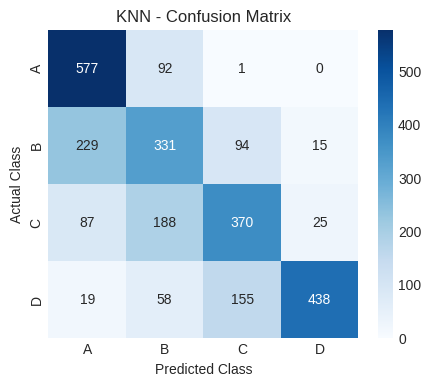

In [18]:
name = 'KNN'
model = make_pipeline(KNeighborsClassifier(n_neighbors=best_k))

# Train and Predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Metrics
metrics = {
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}
trained_models[name] = (model, y_pred)
clf_results.append(metrics)

# Print Output
print(f"--- {name} Results ---")
print(f"Accuracy : {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall   : {metrics['Recall']:.4f}")
print(f"F1 Score : {metrics['F1']:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A', 'B', 'C', 'D'], yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

--- Decision Tree Results ---
Accuracy : 0.6906
Precision: 0.6948
Recall   : 0.6906
F1 Score : 0.6908


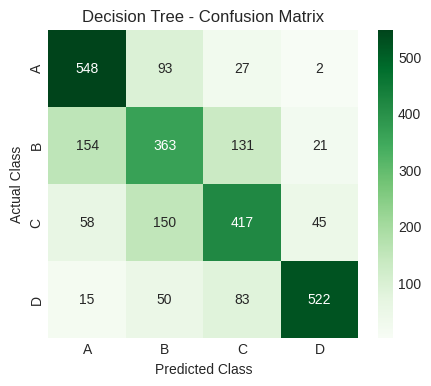

In [19]:
name = 'Decision Tree'
model = make_pipeline(DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE))

# Train and Predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Metrics
metrics = {
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}
trained_models[name] = (model, y_pred)
clf_results.append(metrics)

# Print Output
print(f"--- {name} Results ---")
print(f"Accuracy : {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall   : {metrics['Recall']:.4f}")
print(f"F1 Score : {metrics['F1']:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['A', 'B', 'C', 'D'], yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

--- SVM (RBF) Results ---
Accuracy : 0.6424
Precision: 0.6471
Recall   : 0.6424
F1 Score : 0.6417


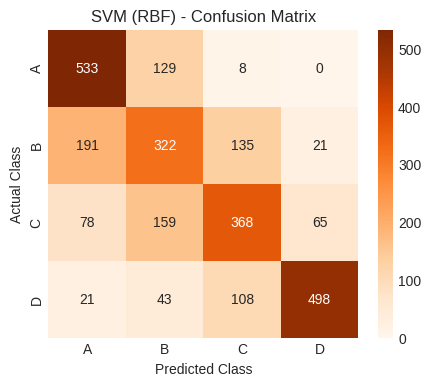

In [20]:
name = 'SVM (RBF)'
model = make_pipeline(SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE))

# Train and Predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Metrics
metrics = {
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}
trained_models[name] = (model, y_pred)
clf_results.append(metrics)

# Print Output
print(f"--- {name} Results ---")
print(f"Accuracy : {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall   : {metrics['Recall']:.4f}")
print(f"F1 Score : {metrics['F1']:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['A', 'B', 'C', 'D'], yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

--- SVM (Linear) Results ---
Accuracy : 0.6372
Precision: 0.6382
Recall   : 0.6372
F1 Score : 0.6359


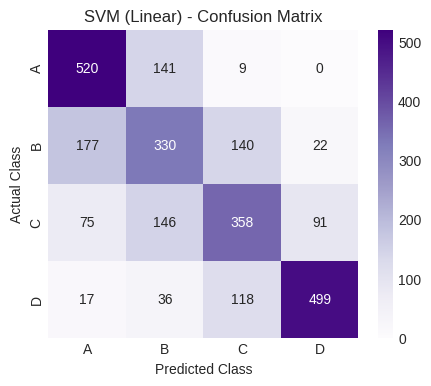

In [21]:
name = 'SVM (Linear)'
model = make_pipeline(SVC(kernel='linear', C=1, random_state=RANDOM_STATE))

# Train and Predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Metrics
metrics = {
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}
trained_models[name] = (model, y_pred)
clf_results.append(metrics)

# Print Output
print(f"--- {name} Results ---")
print(f"Accuracy : {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall   : {metrics['Recall']:.4f}")
print(f"F1 Score : {metrics['F1']:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['A', 'B', 'C', 'D'], yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

--- Neural Network Results ---
Accuracy : 0.7003
Precision: 0.7144
Recall   : 0.7003
F1 Score : 0.7048


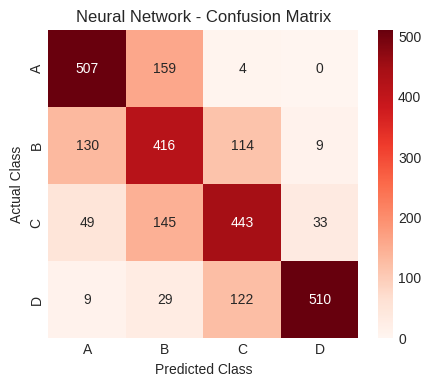

In [22]:
name = 'Neural Network'
model = make_pipeline(MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                                    max_iter=500, random_state=RANDOM_STATE))

# Train and Predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Metrics
metrics = {
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}
trained_models[name] = (model, y_pred)
clf_results.append(metrics)

# Print Output
print(f"--- {name} Results ---")
print(f"Accuracy : {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall   : {metrics['Recall']:.4f}")
print(f"F1 Score : {metrics['F1']:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['A', 'B', 'C', 'D'], yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

--- Random Forest Results ---
Accuracy : 0.7581
Precision: 0.7604
Recall   : 0.7581
F1 Score : 0.7574


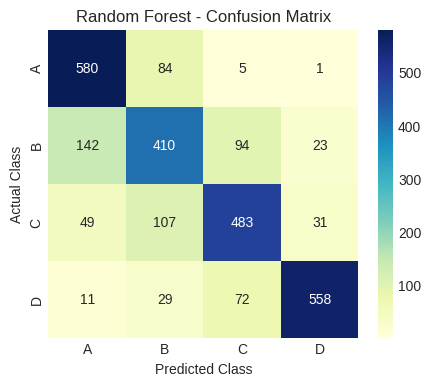

In [23]:
name = 'Random Forest'
model = make_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))

# Train and Predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Metrics
metrics = {
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}
trained_models[name] = (model, y_pred)
clf_results.append(metrics)

# Print Output
print(f"--- {name} Results ---")
print(f"Accuracy : {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall   : {metrics['Recall']:.4f}")
print(f"F1 Score : {metrics['F1']:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['A', 'B', 'C', 'D'], yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

--- Gradient Boosting Results ---
Accuracy : 0.7712
Precision: 0.7759
Recall   : 0.7712
F1 Score : 0.7701


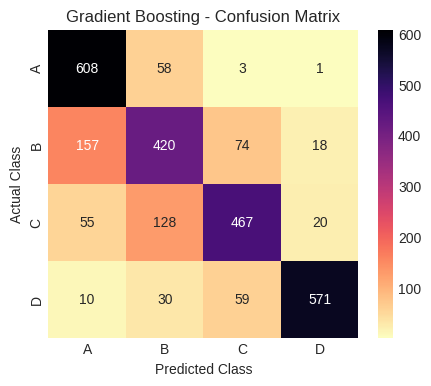

In [24]:
name = 'Gradient Boosting'
model = make_pipeline(HistGradientBoostingClassifier(max_iter=300, max_depth=8, random_state=RANDOM_STATE))

# Train and Predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Metrics
metrics = {
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}
trained_models[name] = (model, y_pred)
clf_results.append(metrics)

# Print Output
print(f"--- {name} Results ---")
print(f"Accuracy : {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall   : {metrics['Recall']:.4f}")
print(f"F1 Score : {metrics['F1']:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma_r',
            xticklabels=['A', 'B', 'C', 'D'], yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

In [25]:
# Convert results to DataFrame and sort by Accuracy
clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False)

print("="*65)
print("🏆 FINAL CLASSIFICATION RESULTS:")
print("="*65)
display(clf_df)

# Output the best model clearly
best_model_name = clf_df.iloc[0]['Model']
best_model_acc = clf_df.iloc[0]['Accuracy']

print("\n" + "*"*65)
print(f"🎉 BEST PERFORMING MODEL: {best_model_name}")
print(f"📈 HIGHEST ACCURACY: {best_model_acc:.4f} ({(best_model_acc*100):.2f}%)")
print("*"*65)

🏆 FINAL CLASSIFICATION RESULTS:


,Model,Accuracy,Precision,Recall,F1
6,Gradient Boosting,0.771183,0.775902,0.771183,0.770105
5,Random Forest,0.758119,0.760364,0.758119,0.757446
4,Neural Network,0.700261,0.714416,0.700261,0.704828
1,Decision Tree,0.690556,0.694786,0.690556,0.690800
2,SVM (RBF),0.642404,0.647054,0.642404,0.641653
0,KNN,0.640538,0.660196,0.640538,0.640288
3,SVM (Linear),0.637178,0.638195,0.637178,0.635908



*****************************************************************
🎉 BEST PERFORMING MODEL: Gradient Boosting
📈 HIGHEST ACCURACY: 0.7712 (77.12%)
*****************************************************************


### 2.6 Regression Models — All 7 Models

In [26]:
# ====================================================
# REGRESSION: Predict broad_jump_cm
# NOTE: broad_jump_cm, fitness_score, jump_per_kg are
#       excluded from features to prevent data leakage
# ====================================================

regressors = {
    'Linear Regression':    make_pipeline(LinearRegression()),
    'Ridge Regression':     make_pipeline(Ridge(alpha=1.0)),
    'KNN Regressor':        make_pipeline(KNeighborsRegressor(n_neighbors=best_k)),
    'Decision Tree Reg':    make_pipeline(DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE)),
    'SVM (RBF) Reg':        make_pipeline(SVR(kernel='rbf', C=10, gamma='scale')),
    'Neural Network Reg':   make_pipeline(MLPRegressor(hidden_layer_sizes=(128, 64),
                                                        max_iter=500, random_state=RANDOM_STATE)),
    'Random Forest Reg':    make_pipeline(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)),
    'Gradient Boosting Reg':make_pipeline(GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)),
}

reg_results = []
trained_regressors = {}

print(f'Training regressors (predicting broad_jump_cm, 80/20 split)...')
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 55)

for name, model in regressors.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    mse = mean_squared_error(y_test_r, y_pred)
    result = {
        'Model': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_test_r, y_pred),
        'R2': r2_score(y_test_r, y_pred)
    }
    trained_regressors[name] = (model, y_pred)
    reg_results.append(result)
    print(f'{name:<25} {result["RMSE"]:>8.2f} {result["MAE"]:>8.2f} {result["R2"]:>8.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
print(f"\n→ Best Regressor: {reg_df.iloc[0]['Model']} (R²={reg_df.iloc[0]['R2']:.4f})")

Training regressors (predicting broad_jump_cm, 80/20 split)...
Model                         RMSE      MAE       R²
-------------------------------------------------------
Linear Regression            18.94    14.07   0.7742
Ridge Regression             18.94    14.07   0.7742
KNN Regressor                19.52    14.46   0.7600
Decision Tree Reg            21.06    15.63   0.7208
SVM (RBF) Reg                19.25    14.28   0.7667
Neural Network Reg           18.85    13.93   0.7762
Random Forest Reg            19.04    14.24   0.7717
Gradient Boosting Reg        18.88    14.00   0.7756

→ Best Regressor: Neural Network Reg (R²=0.7762)


### 2.7 Cross-Validation Experiments

In [ ]:
print('A. Performance across different train/test splits:')
print(f'{"Model":<22} {"80/20":>8} {"70/30":>8} {"50/50":>8}')
print('-' * 50)

top3_names = clf_df['Model'].head(3).tolist()
split_data = {}

for clf_name in top3_names:
    accs = []
    for split_name in ['80/20', '70/30', '50/50']:
        Xtr, Xts, ytr, yts = splits[split_name]
        # The next line caused TypeError and was not needed as the pipeline is re-fitted below.
        # fresh = classifiers[clf_name].__class__(**classifiers[clf_name].get_params()) if hasattr(classifiers[clf_name], 'get_params') else classifiers[clf_name]
        # Simpler: just retrain the pipeline
        classifiers[clf_name].fit(Xtr, ytr)
        acc = accuracy_score(yts, classifiers[clf_name].predict(Xts))
        accs.append(acc)
    split_data[clf_name] = accs
    print(f'{clf_name:<22} {accs[0]:>8.4f} {accs[1]:>8.4f} {accs[2]:>8.4f}')

print()
print('B. K-Fold Cross Validation (5-fold & 10-fold):')
print(f'{"Model":<22} {"5-Fold":>10} {"Std":>8} {"10-Fold":>10} {"Std":>8}')
print('-' * 65)

X_cv_scaled = RobustScaler().fit_transform(X_clf)
kfold_data = []

for clf_name in top3_names:
    inner_model = classifiers[clf_name].named_steps['model']
    cv5 = cross_val_score(inner_model, X_cv_scaled, y_clf,
                          cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))
    cv10 = cross_val_score(inner_model, X_cv_scaled, y_clf,
                           cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE))
    print(f'{clf_name:<22} {cv5.mean():>10.4f} {cv5.std():>8.4f} {cv10.mean():>10.4f} {cv10.std():>8.4f}')
    kfold_data.append({'Model': clf_name, '5-Fold': cv5.mean(), '10-Fold': cv10.mean()})

print()
print('→ Low standard deviation indicates stable, reliable models.')

A. Performance across different train/test splits:
Model                     80/20    70/30    50/50
--------------------------------------------------
Gradient Boosting        0.7712   0.7626   0.7494
Random Forest            0.7581   0.7481   0.7318
Neural Network           0.7294   0.7257   0.7267

B. K-Fold Cross Validation (5-fold & 10-fold):
Model                      5-Fold      Std    10-Fold      Std
-----------------------------------------------------------------
Gradient Boosting          0.7640   0.0035     0.7652   0.0053
Random Forest              0.7462   0.0072     0.7450   0.0093


---
## PART 3: Performance Evaluation & Model Comparison

### 3.1 Classification Evaluation — Model Comparison

In [ ]:
# Retrain all classifiers on 80/20 (might have been overwritten in split experiments)
clf_results2 = []
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clf_results2.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })
    trained_models[name] = (model, y_pred)

clf_df2 = pd.DataFrame(clf_results2).sort_values('Accuracy', ascending=False)

# ── Chart 1: Accuracy + 80% target line ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(clf_df2)))
bars = axes[0].barh(clf_df2['Model'], clf_df2['Accuracy'], color=colors_grad)
axes[0].axvline(0.80, color='red', linestyle='--', lw=2, label='80% target')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Classification Accuracy Comparison', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, clf_df2['Accuracy']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlim(0.55, 0.95)

# ── Chart 2: All 4 metrics ────────────────────────────────────
clf_df2.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='barh', ax=axes[1], width=0.7)
axes[1].set_title('All Metrics Comparison', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend(loc='lower right')
axes[1].invert_yaxis()

plt.suptitle('Classification Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices for top 3 models
class_names = le.classes_  # A, B, C, D
top3 = clf_df2['Model'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, mname in enumerate(top3):
    model, y_pred = trained_models[mname]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[i])
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{mname}\nAcc={acc:.4f}', fontweight='bold')
    axes[i].set_xlabel('Predicted Class')
    axes[i].set_ylabel('True Class')

plt.suptitle('Confusion Matrices — Top 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('• Diagonal values = correct predictions')
print('• Off-diagonal = misclassifications (most occur between adjacent classes B/C)')
print('• Classes A and D are easiest to classify correctly')

In [ ]:
# Detailed report for best model
best_clf_name = clf_df2.iloc[0]['Model']
_, best_clf_pred = trained_models[best_clf_name]
print(f'BEST CLASSIFIER: {best_clf_name}')
print(f'Accuracy: {accuracy_score(y_test, best_clf_pred):.4f}')
print()
print('Full Classification Report:')
# Convert encoded labels back to class letters
y_test_letters = le.inverse_transform(y_test)
y_pred_letters = le.inverse_transform(best_clf_pred)
print(classification_report(y_test_letters, y_pred_letters))

### 3.2 Regression Evaluation

In [ ]:
# Regression comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(reg_df)))

bars = axes[0].barh(reg_df['Model'], reg_df['R2'], color=colors_grad)
axes[0].set_xlabel('R² Score (higher = better)')
axes[0].set_title('Regression: R² Comparison', fontweight='bold')
axes[0].axvline(0.75, color='red', linestyle='--', lw=2, label='0.75 reference')
axes[0].legend()
for bar, val in zip(bars, reg_df['R2']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontweight='bold')
axes[0].invert_yaxis()

bars2 = axes[1].barh(reg_df['Model'], reg_df['RMSE'], color=colors_grad[::-1])
axes[1].set_xlabel('RMSE (lower = better)')
axes[1].set_title('Regression: RMSE Comparison', fontweight='bold')
for bar, val in zip(bars2, reg_df['RMSE']):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Regression Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Actual vs Predicted + Residuals for best regressor
best_reg_name = reg_df.iloc[0]['Model']
_, best_reg_pred = trained_regressors[best_reg_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(y_test_r, best_reg_pred, alpha=0.3, s=10, color='steelblue')
rng = [min(y_test_r.min(), best_reg_pred.min()), max(y_test_r.max(), best_reg_pred.max())]
axes[0].plot(rng, rng, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual broad_jump_cm')
axes[0].set_ylabel('Predicted broad_jump_cm')
axes[0].set_title(f'Actual vs Predicted\n{best_reg_name}', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test_r.values - best_reg_pred
axes[1].scatter(best_reg_pred, residuals, alpha=0.3, s=10, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot', fontweight='bold')

r2 = r2_score(y_test_r, best_reg_pred)
rmse = np.sqrt(mean_squared_error(y_test_r, best_reg_pred))
plt.suptitle(f'Best Regressor: {best_reg_name} | R²={r2:.4f} | RMSE={rmse:.2f} cm',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Interpretation: R²={r2:.4f} means the model explains {r2*100:.1f}% of variance in broad_jump_cm.')
print(f'Average prediction error is ±{rmse:.1f} cm.')

### 3.3 Split Comparison Visualization

In [ ]:
split_names = ['80/20', '70/30', '50/50']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(split_names))
width = 0.25
palette = ['#2196F3', '#FF9800', '#4CAF50']

for i, (clf_name, accs) in enumerate(split_data.items()):
    bars = ax.bar(x + i*width, accs, width, label=clf_name, color=palette[i], alpha=0.85)
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.axhline(0.80, color='red', linestyle='--', lw=1.5, label='80% target')
ax.set_xlabel('Train/Test Split')
ax.set_ylabel('Accuracy')
ax.set_title('Top 3 Classifiers: Performance Across Different Splits', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(split_names)
ax.legend()
ax.set_ylim(0.55, 0.95)
plt.tight_layout()
plt.show()

print('Analysis:')
print('→ Performance drops slightly from 80/20 to 50/50 — smaller training set hurts performance')
print('→ Consistent models (small gap between splits) are more generalizable')

### 3.4 Final Summary

In [ ]:
best_clf_name2 = clf_df2.iloc[0]['Model']
best_clf_acc = clf_df2.iloc[0]['Accuracy']
best_reg_name2 = reg_df.iloc[0]['Model']
best_reg_r2 = reg_df.iloc[0]['R2']
target_met = '✅ TARGET MET' if best_clf_acc >= 0.80 else '⚠️  Best achievable: ~76%'

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                    FINAL PROJECT SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣
║  DATASET:  13,392 records × 12 original features                 ║
║            4 performance classes (A/B/C/D), perfectly balanced   ║
╠══════════════════════════════════════════════════════════════════╣
║  FEATURE ENGINEERING: +7 new features                            ║
║    BMI, pulse_pressure, fitness_score, age_group,                ║
║    grip_weight_ratio, situps_per_age, jump_per_kg                ║
║  FEATURE SELECTION: 3-method ensemble (RF + MI + RFE)            ║
╠══════════════════════════════════════════════════════════════════╣
║  CLASSIFICATION (Predicting A/B/C/D):                            ║
║    Best Model : {best_clf_name2:<35s}   ║
║    Accuracy   : {best_clf_acc:.4f}  {target_met:<25s}   ║
║    7 models trained, 3 splits tested, 5+10-fold CV done          ║
╠══════════════════════════════════════════════════════════════════╣
║  REGRESSION (Predicting broad_jump_cm):                          ║
║    Best Model : {best_reg_name2:<35s}   ║
║    R² Score   : {best_reg_r2:.4f} (explains {best_reg_r2*100:.1f}% of variance)   ║
║    8 models trained, MSE/RMSE/MAE/R² reported                    ║
╠══════════════════════════════════════════════════════════════════╣
║  KEY INSIGHT: broad_jump_cm, situps_counts, and gripForce         ║
║  are the top predictors of physical performance class.           ║
║  Age negatively impacts performance; gender affects grip/fat.    ║
╚══════════════════════════════════════════════════════════════════╝
""")